# Implied Volatility Surface

## 1. Research Objective

We now move back to the notebook on implied volatility, and measure how volatility varies across different strike prices and maturities. The aim is to create volatility smiles and surfaces and use these to examine how market prices deviate from the constant-volatility assumption seen in the Black-Scholes model. 

## 2. Implied Volatility

Under the Black–Scholes model, the price of a European call option is

$$
C_{\text{BS}}
=
S_0N(d_1)
-
Ke^{-rT}N(d_2),
$$

where

$$
d_1
=
\frac{
\ln(S_0/K)
+
\left(r+\frac{1}{2}\sigma^2\right)T
}{
\sigma\sqrt{T}
},
$$

and

$$
d_2=d_1-\sigma\sqrt{T}.
$$

Implied volatility is the value $\sigma_{\text{IV}}$ that equates the Black–Scholes price with the observed market price:

$$
C_{\text{BS}}
\left(
S_0,K,r,\sigma_{\text{IV}},T
\right)
=
C_{\text{market}}.
$$

Unlike historical volatility, implied volatility is inferred from current option prices and reflects the market's risk-neutral assessment of future uncertainty.

## 3. Volatility Smiles and Surfaces

The Black–Scholes model assumes that volatility is constant across strike prices and maturities.

Observed option prices generally imply different volatility levels for different contracts. For a fixed maturity, the relationship between implied volatility and strike is known as the volatility smile or skew.

Across multiple maturities, implied volatility can be represented as a surface:

$$
\sigma_{\text{IV}}=\sigma_{\text{IV}}(K,T).
$$

The shape of this surface reflects market expectations, demand for option protection and the pricing of tail risk.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import datetime, timezone
from scipy.optimize import brentq
from scipy.stats import norm

## 4. Market Data

Option-chain data will be collected for SPY across several available expiration dates.

In [2]:
ticker_symbol = "SPY"

ticker = yf.Ticker(ticker_symbol)
expiration_dates = ticker.options

expiration_dates[:10]

('2026-07-31',
 '2026-08-03',
 '2026-08-04',
 '2026-08-05',
 '2026-08-06',
 '2026-08-07',
 '2026-08-14',
 '2026-08-21',
 '2026-08-28',
 '2026-08-31')

In [3]:
spot_history = ticker.history(period="5d")

S0 = float(spot_history["Close"].dropna().iloc[-1])

print(f"Underlying Asset: {ticker_symbol}")
print(f"Spot Price: {S0:.2f}")
print(f"Available Expirations: {len(expiration_dates)}")

Underlying Asset: SPY
Spot Price: 742.15
Available Expirations: 29


In [4]:
selected_expirations = expiration_dates[:6]

selected_expirations

('2026-07-31',
 '2026-08-03',
 '2026-08-04',
 '2026-08-05',
 '2026-08-06',
 '2026-08-07')

In [5]:
option_data = []

valuation_date = datetime.now(timezone.utc).date()

for expiration in selected_expirations:
    chain = ticker.option_chain(expiration)
    calls = chain.calls.copy()

    expiry_date = datetime.strptime(
        expiration,
        "%Y-%m-%d"
    ).date()

    time_to_maturity = (
        expiry_date - valuation_date
    ).days / 365

    calls["expiration"] = expiry_date
    calls["time_to_maturity"] = time_to_maturity

    option_data.append(calls)

calls = pd.concat(
    option_data,
    ignore_index=True
)

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiration,time_to_maturity
0,SPY260731C00375000,2026-06-16 15:33:31+00:00,375.0,378.45,362.96,366.28,0.0,0.0,4.0,4,0.000010,True,REGULAR,USD,2026-07-31,0.0
1,SPY260731C00380000,2026-07-30 19:12:20+00:00,380.0,362.00,359.31,362.62,0.0,0.0,1.0,1,4.539067,True,REGULAR,USD,2026-07-31,0.0
2,SPY260731C00395000,2026-07-09 17:33:19+00:00,395.0,357.62,344.31,347.62,0.0,0.0,NaN,11,4.296880,True,REGULAR,USD,2026-07-31,0.0
3,SPY260731C00400000,2026-07-17 19:41:31+00:00,400.0,343.52,339.31,342.62,0.0,0.0,1.0,1,4.218755,True,REGULAR,USD,2026-07-31,0.0
4,SPY260731C00405000,2026-06-18 14:24:33+00:00,405.0,343.87,332.99,336.30,0.0,0.0,1.0,1,0.000010,True,REGULAR,USD,2026-07-31,0.0


## 5. Data Cleaning

Raw option-chain data may contain contracts with missing prices, zero bid quotes or insufficient liquidity. Such observations can produce unreliable implied volatility estimates, so we need to clean the data.


In [8]:
calls = calls.copy()

calls = calls[
    (
        (calls["bid"] > 0)
        &
        (calls["ask"] > 0)
    )
]

calls["mid_price"] = (
    calls["bid"]
    + calls["ask"]
) / 2

calls = calls[
    (
        calls["time_to_maturity"] > 0
    )
]

calls = calls.dropna(
    subset=[
        "strike",
        "mid_price",
        "time_to_maturity",
    ]
)

calls = calls.reset_index(drop=True)

calls[
    [
        "strike",
        "bid",
        "ask",
        "mid_price",
        "time_to_maturity",
        "volume",
        "openInterest",
    ]
].head()

,strike,bid,ask,mid_price,time_to_maturity,volume,openInterest
0,665.0,74.31,77.63,75.970,0.008219,4.0,5
1,685.0,54.16,57.91,56.035,0.008219,1.0,2
2,695.0,44.34,47.74,46.040,0.008219,3.0,2
3,700.0,39.35,42.52,40.935,0.008219,4.0,15
4,705.0,34.43,37.66,36.045,0.008219,21.0,19


In [9]:
print(f"Number of Contracts: {len(calls)}")

Number of Contracts: 342


## 6. Black–Scholes Pricing and Numerical Inversion

Implied volatility is obtained by solving

$$
f(\sigma)
= C_{\text{BS}}(\sigma)-C_{\text{market}} = 0$$

Brent's method searches for a root within a volatility interval where $f(\sigma)$ changes sign. It combines the reliability of bisection with faster interpolation methods.

In [10]:
def black_scholes_call_price(S, K, r, sigma, T):
    if S <= 0 or K <= 0:
        return np.nan

    if sigma <= 0 or T <= 0:
        return np.nan

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return call_price

In [11]:
def implied_volatility_call(
    market_price,
    S,
    K,
    r,
    T,
    sigma_lower=1e-6,
    sigma_upper=5.0,
):
    if (
        market_price <= 0
        or S <= 0
        or K <= 0
        or T <= 0
    ):
        return np.nan

    lower_bound = max(
        S - K * np.exp(-r * T),
        0,
    )

    upper_bound = S

    if not lower_bound <= market_price < upper_bound:
        return np.nan

    def objective(sigma):
        return (
            black_scholes_call_price(
                S,
                K,
                r,
                sigma,
                T,
            )
            - market_price
        )

    try:
        implied_volatility = brentq(
            objective,
            sigma_lower,
            sigma_upper,
            xtol=1e-10,
            maxiter=200,
        )

        return implied_volatility

    except ValueError:
        return np.nan

In [12]:
risk_free_rate = 0.05 # Constant risk-free interest rate 

In [14]:
calls["implied_volatility"] = calls.apply(
    lambda row: implied_volatility_call(
        market_price=row["mid_price"],
        S=S0,
        K=row["strike"],
        r=risk_free_rate,
        T=row["time_to_maturity"],
    ),
    axis=1,
)

calls[
    [
        "expiration",
        "strike",
        "mid_price",
        "time_to_maturity",
        "implied_volatility",
    ]
].head()

,expiration,strike,mid_price,time_to_maturity,implied_volatility
0,2026-08-03,665.0,75.970,0.008219,NaN
1,2026-08-03,685.0,56.035,0.008219,NaN
2,2026-08-03,695.0,46.040,0.008219,NaN
3,2026-08-03,700.0,40.935,0.008219,NaN
4,2026-08-03,705.0,36.045,0.008219,NaN


In [15]:
valid_iv = calls.dropna(
    subset=["implied_volatility"]
).copy()

valid_iv = valid_iv[
    valid_iv["implied_volatility"].between(
        0.01,
        2.00,
    )
].reset_index(drop=True)

print(f"Contracts Before IV Filtering: {len(calls)}")
print(f"Contracts With Valid IV: {len(valid_iv)}")

Contracts Before IV Filtering: 342
Contracts With Valid IV: 230


In [16]:
valid_iv[
    [
        "expiration",
        "strike",
        "mid_price",
        "implied_volatility",
        "volume",
        "openInterest",
    ]
].head()

,expiration,strike,mid_price,implied_volatility,volume,openInterest
0,2026-08-03,736.0,6.610,0.067641,519.0,2005
1,2026-08-03,737.0,5.775,0.072703,1489.0,1262
2,2026-08-03,738.0,4.990,0.075967,7947.0,1802
3,2026-08-03,739.0,4.445,0.086663,11259.0,1803
4,2026-08-03,740.0,3.855,0.090816,16217.0,1637


## 7. Liquidity and Moneyness Filters

Implied volatility estimates are most reliable for actively quoted contracts with moderate bid–ask spreads.

Relative bid–ask spread is defined as

$$
\text{Relative Spread}
=
\frac{\text{Ask}-\text{Bid}}{\text{Mid Price}}.
$$

Moneyness is measured using the strike-to-spot ratio

$$
\text{Moneyness}
=
\frac{K}{S_0}.
$$

The analysis retains contracts with positive open interest, relative spreads below $20\%$, and strikes between $80\%$ and $120\%$ of the underlying spot price.

In [19]:
valid_iv["relative_spread"] = (
    valid_iv["ask"] - valid_iv["bid"]
) / valid_iv["mid_price"]

valid_iv["moneyness"] = (
    valid_iv["strike"] / S0
)

filtered_iv = valid_iv[
    (
        valid_iv["relative_spread"] <= 0.20
    )
    &
    (
        valid_iv["openInterest"].fillna(0) > 0
    )
    &
    (
        valid_iv["moneyness"].between(
            0.80,
            1.20,
        )
    )
].copy()

filtered_iv = filtered_iv.reset_index(drop=True)

print(f"Contracts Before Liquidity Filtering: {len(valid_iv)}")
print(f"Contracts After Liquidity Filtering: {len(filtered_iv)}")

Contracts Before Liquidity Filtering: 230
Contracts After Liquidity Filtering: 144


In [20]:
filtered_iv[
    [
        "expiration",
        "strike",
        "moneyness",
        "mid_price",
        "relative_spread",
        "openInterest",
        "implied_volatility",
    ]
].head()

,expiration,strike,moneyness,mid_price,relative_spread,openInterest,implied_volatility
0,2026-08-03,736.0,0.991713,6.610,0.009077,2005,0.067641
1,2026-08-03,737.0,0.993061,5.775,0.008658,1262,0.072703
2,2026-08-03,738.0,0.994408,4.990,0.004008,1802,0.075967
3,2026-08-03,739.0,0.995756,4.445,0.006749,1803,0.086663
4,2026-08-03,740.0,0.997103,3.855,0.007782,1637,0.090816


## 8. Volatility Smiles

A volatility smile represents implied volatility across strike prices for a fixed expiration date.

If the Black–Scholes constant-volatility assumption held exactly, implied volatility would be constant across strikes. Variation in the observed smile therefore reflects departures from the model assumptions.

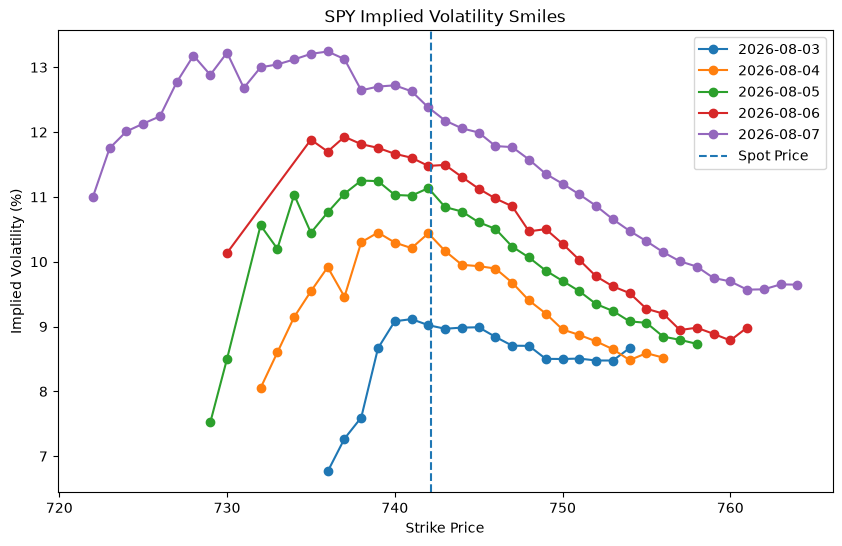

In [21]:
smile_expirations = (
    filtered_iv["expiration"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

plt.figure(figsize=(10, 6))

for expiration in smile_expirations:
    smile_data = filtered_iv[
        filtered_iv["expiration"] == expiration
    ].sort_values("strike")

    plt.plot(
        smile_data["strike"],
        smile_data["implied_volatility"] * 100,
        marker="o",
        label=str(expiration),
    )

plt.axvline(
    S0,
    linestyle="--",
    label="Spot Price",
)

plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.title("SPY Implied Volatility Smiles")
plt.legend()
plt.show()

As we can see the implied volatility smiles are non-constant, which contradicts one of the most fundamental Black-Scholes assumptions. 

## 9. Implied Volatility Surfaces

We now extend this theory across multiple maturities.

In [22]:
from scipy.interpolate import griddata

surface_data = filtered_iv[
    [
        "strike",
        "time_to_maturity",
        "implied_volatility",
    ]
].dropna()

strike_grid = np.linspace(
    surface_data["strike"].min(),
    surface_data["strike"].max(),
    100,
)

maturity_grid = np.linspace(
    surface_data["time_to_maturity"].min(),
    surface_data["time_to_maturity"].max(),
    100,
)

strike_mesh, maturity_mesh = np.meshgrid(
    strike_grid,
    maturity_grid,
)

iv_surface = griddata(
    points=(
        surface_data["strike"],
        surface_data["time_to_maturity"],
    ),
    values=surface_data["implied_volatility"],
    xi=(
        strike_mesh,
        maturity_mesh,
    ),
    method="linear",
)

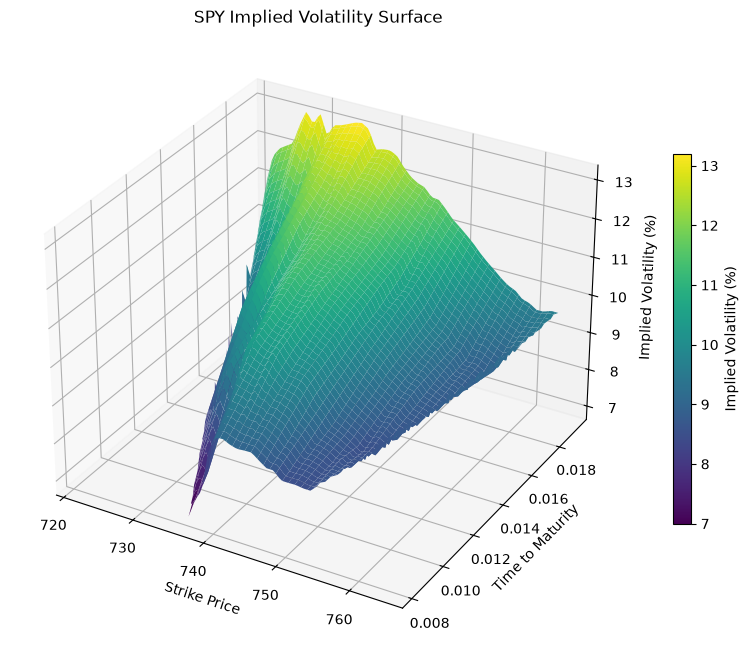

In [23]:
fig = plt.figure(figsize=(12, 8))

ax = fig.add_subplot(
    111,
    projection="3d",
)

surface = ax.plot_surface(
    strike_mesh,
    maturity_mesh,
    iv_surface * 100,
    cmap="viridis",
    edgecolor="none",
)

ax.set_xlabel("Strike Price")
ax.set_ylabel("Time to Maturity")
ax.set_zlabel("Implied Volatility (%)")
ax.set_title("SPY Implied Volatility Surface")

fig.colorbar(
    surface,
    ax=ax,
    shrink=0.6,
    label="Implied Volatility (%)",
)

plt.show()

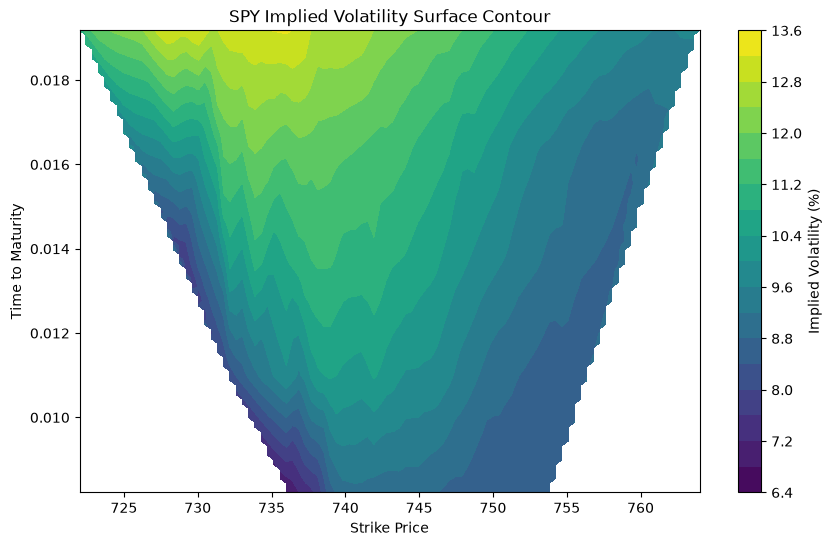

In [24]:
plt.figure(figsize=(10, 6))

contour = plt.contourf(
    strike_mesh,
    maturity_mesh,
    iv_surface * 100,
    levels=20,
    cmap="viridis",
)

plt.colorbar(
    contour,
    label="Implied Volatility (%)",
)

plt.xlabel("Strike Price")
plt.ylabel("Time to Maturity")
plt.title("SPY Implied Volatility Surface Contour")

plt.show()

This plot is a 2D representation of the same volatility surface.